In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.tree import (
    DecisionTreeClassifier
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GridSearchCV
)

import joblib

In [7]:
df = pd.read_csv("titanic_cleaned.csv")

In [8]:
# --------------------------------
# 1. Load cleaned Titanic data
# --------------------------------

df = pd.read_csv("titanic_cleaned.csv")

print("Cleaned Titanic dataset loaded successfully.")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Cleaned Titanic dataset loaded successfully.

Shape:
(889, 13)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True


In [9]:
# --------------------------------
# 2. Separate features and target
# --------------------------------

X = df.drop(
    columns=["survived"]
)

y = df["survived"]

print("Features shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape:
(889, 12)

Target shape:
(889,)

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64


In [10]:
# --------------------------------
# 2. Separate features and target
# --------------------------------

X = df.drop(
    columns=["survived"]
)

y = df["survived"]

print("Features shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape:
(889, 12)

Target shape:
(889,)

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64


In [11]:
# --------------------------------
# 3. Stratified train/test split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:")
print(X_train.shape)

print("\nTesting set shape:")
print(X_test.shape)

Training set shape:
(711, 12)

Testing set shape:
(178, 12)


In [12]:
# --------------------------------
# 4. Check target proportions
# --------------------------------

print("Original target proportions:")
print(
    y.value_counts(
        normalize=True
    ).sort_index()
)

print("\nTraining target proportions:")
print(
    y_train.value_counts(
        normalize=True
    ).sort_index()
)

print("\nTesting target proportions:")
print(
    y_test.value_counts(
        normalize=True
    ).sort_index()
)

Original target proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training target proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target proportions:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [13]:
# --------------------------------
# 5. Select modeling features
# --------------------------------

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

model_features = (
    numeric_features +
    categorical_features
)

X = df[model_features]

y = df["survived"]


print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nAll modeling features:")
print(model_features)

print("\nFeature shape:")
print(X.shape)

Numerical features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked']

All modeling features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']

Feature shape:
(889, 7)


In [14]:
# --------------------------------
# 6. Stratified train/test split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:")
print(X_train.shape)

print("\nTesting shape:")
print(X_test.shape)

Training shape:
(711, 7)

Testing shape:
(178, 7)


In [15]:
print("\nTraining target proportions:")
print(
    y_train.value_counts(
        normalize=True
    ).sort_index()
)

print("\nTesting target proportions:")
print(
    y_test.value_counts(
        normalize=True
    ).sort_index()
)


Training target proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target proportions:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [16]:
# --------------------------------
# 7. Numerical preprocessing
# --------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [17]:
# --------------------------------
# 8. Categorical preprocessing
# --------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [18]:
# --------------------------------
# 7. Numerical preprocessing
# --------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [19]:
# --------------------------------
# 9. Combine preprocessing
# --------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [20]:
# --------------------------------
# 10. Logistic Regression pipeline
# --------------------------------

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print(
    "Logistic Regression pipeline created."
)

Logistic Regression pipeline created.


In [21]:
# --------------------------------
# 11. Train Logistic Regression
# --------------------------------

logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression trained successfully."
)

Logistic Regression trained successfully.


In [22]:
# --------------------------------
# 11. Train Logistic Regression
# --------------------------------

logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression trained successfully."
)

Logistic Regression trained successfully.


In [23]:
# --------------------------------
# 12. Logistic predictions
# --------------------------------

y_pred_logistic = (
    logistic_pipeline.predict(X_test)
)

y_prob_logistic = (
    logistic_pipeline.predict_proba(X_test)[:, 1]
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [24]:
# --------------------------------
# 13. Evaluation function
# --------------------------------

def evaluate_classifier(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    print(
        f"\n{'=' * 50}"
    )

    print(
        f"{model_name} Evaluation"
    )

    print(
        f"{'=' * 50}"
    )

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )

    print("\nConfusion Matrix:")

    print(cm)

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [25]:
logistic_results = evaluate_classifier(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)


Logistic Regression Evaluation
Accuracy : 0.8090
Precision: 0.7833
Recall   : 0.6912
F1 Score : 0.7344
ROC-AUC  : 0.8610

Confusion Matrix:
[[97 13]
 [21 47]]


In [26]:
from sklearn.pipeline import Pipeline

In [27]:

decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

print(
    "Decision Tree pipeline created successfully."
)

Decision Tree pipeline created successfully.


In [28]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

print(
    "Decision Tree trained successfully."
)

Decision Tree trained successfully.


In [29]:
y_pred_tree = decision_tree_pipeline.predict(
    X_test
)

y_prob_tree = decision_tree_pipeline.predict_proba(
    X_test
)[:, 1]

print(
    "Decision Tree predictions generated successfully."
)

Decision Tree predictions generated successfully.


In [30]:
decision_tree_results = evaluate_classifier(
    "Decision Tree",
    y_test,
    y_pred_tree,
    y_prob_tree
)


Decision Tree Evaluation
Accuracy : 0.7697
Precision: 0.6901
Recall   : 0.7206
F1 Score : 0.7050
ROC-AUC  : 0.7541

Confusion Matrix:
[[88 22]
 [19 49]]


In [31]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

print(
    "Random Forest pipeline created successfully."
)

Random Forest pipeline created successfully.


In [32]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print(
    "Random Forest trained successfully."
)

Random Forest trained successfully.


In [33]:
y_pred_rf = random_forest_pipeline.predict(
    X_test
)

y_prob_rf = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

print(
    "Random Forest predictions generated successfully."
)

Random Forest predictions generated successfully.


In [34]:
random_forest_results = evaluate_classifier(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


Random Forest Evaluation
Accuracy : 0.8202
Precision: 0.7812
Recall   : 0.7353
F1 Score : 0.7576
ROC-AUC  : 0.8179

Confusion Matrix:
[[96 14]
 [18 50]]


In [35]:
classification_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results
])

print("Classification Model Comparison:")
display(classification_results)

Classification Model Comparison:


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [37]:
classification_results.to_csv(
    "C:\\Users\\user\\Desktop\\AI-ML Course\\zepto-ai-ml-capstone\\analytics\\outputs\\charts\\tables\\classification_model_comparison.csv",
    index=False
)

print(
    "Classification model comparison saved successfully."
)

Classification model comparison saved successfully.


In [38]:
best_baseline = classification_results.loc[
    classification_results["roc_auc"].idxmax()
]

print("Best baseline model:")
print(best_baseline)

Best baseline model:
model        Logistic Regression
accuracy                0.808989
precision               0.783333
recall                  0.691176
f1                      0.734375
roc_auc                 0.860963
Name: 0, dtype: object


In [39]:
class_counts = y_train.value_counts()

class_percentages = (
    y_train.value_counts(normalize=True) * 100
)

print("Training class counts:")
print(class_counts)

print("\nTraining class percentages:")
print(class_percentages.round(2))

Training class counts:
survived
0    439
1    272
Name: count, dtype: int64

Training class percentages:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64


In [40]:
balanced_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print(
    "Class-weighted Random Forest pipeline created."
)

Class-weighted Random Forest pipeline created.


In [41]:
balanced_rf_pipeline.fit(
    X_train,
    y_train
)

print(
    "Class-weighted Random Forest trained."
)

Class-weighted Random Forest trained.


In [44]:
y_pred_balanced_rf = (
    balanced_rf_pipeline.predict(X_test)
)

y_prob_balanced_rf = (
    balanced_rf_pipeline.predict_proba(X_test)[:, 1]
)

In [45]:
balanced_rf_results = evaluate_classifier(
    "Random Forest - Balanced",
    y_test,
    y_pred_balanced_rf,
    y_prob_balanced_rf
)


Random Forest - Balanced Evaluation
Accuracy : 0.8146
Precision: 0.7692
Recall   : 0.7353
F1 Score : 0.7519
ROC-AUC  : 0.8176

Confusion Matrix:
[[95 15]
 [18 50]]


In [46]:
display(classification_results)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [47]:
rf_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

print("Random Forest tuning pipeline created.")

Random Forest tuning pipeline created.


In [48]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__class_weight": [None, "balanced"]
}

print("Parameter grid created.")

Parameter grid created.


In [49]:
grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV created.")

GridSearchCV created.


In [50]:
grid_search.fit(
    X_train,
    y_train
)

print("GridSearchCV completed successfully.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV completed successfully.


In [51]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [52]:
print(
    "Best cross-validation ROC-AUC:",
    grid_search.best_score_
)

Best cross-validation ROC-AUC: 0.8722680963237389


In [53]:
best_rf_pipeline = grid_search.best_estimator_

y_pred_tuned = best_rf_pipeline.predict(
    X_test
)

y_prob_tuned = best_rf_pipeline.predict_proba(
    X_test
)[:, 1]

In [54]:
tuned_rf_results = evaluate_classifier(
    "Tuned Random Forest",
    y_test,
    y_pred_tuned,
    y_prob_tuned
)


Tuned Random Forest Evaluation
Accuracy : 0.7978
Precision: 0.7857
Recall   : 0.6471
F1 Score : 0.7097
ROC-AUC  : 0.8231

Confusion Matrix:
[[98 12]
 [24 44]]


In [57]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_results = grid_results.sort_values(
    by="rank_test_score"
)

grid_results.to_csv(
  r"C:\Users\user\Desktop\AI-ML Course\zepto-ai-ml-capstone\analytics\outputs\charts\tables\random_forest_gridsearch_results.csv",
  index=False
)

print(
    "GridSearchCV results saved successfully."
)

GridSearchCV results saved successfully.


In [58]:
final_classification_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    balanced_rf_results,
    tuned_rf_results
])

display(
    final_classification_comparison
)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914
3,Random Forest - Balanced,0.814607,0.769231,0.735294,0.751880,0.817580
4,Tuned Random Forest,0.797753,0.785714,0.647059,0.709677,0.823128


In [59]:
final_classification_comparison.to_csv(
    r"C:\Users\user\Desktop\AI-ML Course\zepto-ai-ml-capstone\analytics\outputs\charts\tables\final_classification_comparison.csv",
    index=False
)

print(
    "Final classification comparison saved successfully."
)

Final classification comparison saved successfully.


In [60]:
regression_df = df.copy()

X_reg = regression_df.drop(
    columns=["fare"]
)

y_reg = regression_df["fare"]

print("Regression features:")
print(X_reg.columns.tolist())

print("\nRegression target:")
print("fare")

print("\nX shape:")
print(X_reg.shape)

print("\ny shape:")
print(y_reg.shape)

Regression features:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']

Regression target:
fare

X shape:
(889, 12)

y shape:
(889,)


In [61]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:")
print(X_reg_train.shape)

print("\nRegression testing shape:")
print(X_reg_test.shape)

Regression training shape:
(711, 12)

Regression testing shape:
(178, 12)


In [62]:
numeric_reg_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_reg_features = [
    "sex",
    "embarked"
]

print("Numerical regression features:")
print(numeric_reg_features)

print("\nCategorical regression features:")
print(categorical_reg_features)

Numerical regression features:
['pclass', 'age', 'sibsp', 'parch']

Categorical regression features:
['sex', 'embarked']


In [63]:

numeric_reg_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_reg_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [64]:
regression_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_reg_transformer,
            numeric_reg_features
        ),
        (
            "categorical",
            categorical_reg_transformer,
            categorical_reg_features
        )
    ]
)

print(
    "Regression preprocessing created successfully."
)

Regression preprocessing created successfully.


In [65]:
linear_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            regression_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

print(
    "Linear Regression pipeline created successfully."
)

Linear Regression pipeline created successfully.


In [66]:
linear_regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print(
    "Linear Regression trained successfully."
)

Linear Regression trained successfully.


In [67]:
y_pred_fare = linear_regression_pipeline.predict(
    X_reg_test
)

print(
    "Fare predictions generated successfully."
)

Fare predictions generated successfully.


In [68]:
mae = mean_absolute_error(
    y_reg_test,
    y_pred_fare
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_pred_fare
    )
)

r2 = r2_score(
    y_reg_test,
    y_pred_fare
)

print("Linear Regression Results")
print("=" * 40)

print(
    f"MAE : {mae:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"R²  : {r2:.4f}"
)

Linear Regression Results
MAE : 21.1386
RMSE: 41.7465
R²  : 0.3468


In [69]:
residuals = (
    y_reg_test - y_pred_fare
)

print("Residual summary:")
print(residuals.describe())

Residual summary:
count    178.000000
mean      -1.158519
std       41.848141
min      -53.376547
25%      -20.427122
50%       -5.038245
75%       10.671055
max      433.008196
Name: fare, dtype: float64


In [70]:
import matplotlib.pyplot as plt

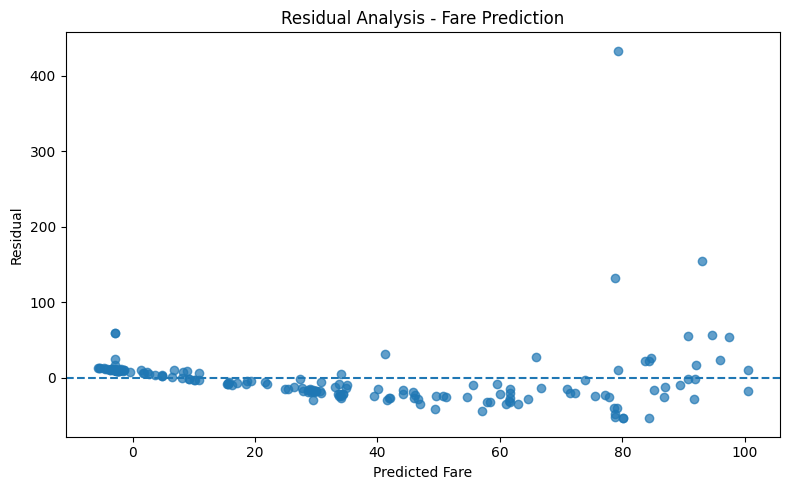

In [71]:
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    y_pred_fare,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Residual Analysis - Fare Prediction"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residual"
)

plt.tight_layout()

plt.savefig(
    "C:\\Users\\user\\Desktop\\AI-ML Course\\zepto-ai-ml-capstone\\analytics\\outputs\\charts\\fare_residuals.png",
    bbox_inches="tight"
)

plt.show()

In [74]:
regression_results = pd.DataFrame({
    "model": [
        "Linear Regression"
    ],
    "MAE": [
        mae
    ],
    "RMSE": [
        rmse
    ],
    "R2": [
        r2
    ]
})

display(regression_results)

,model,MAE,RMSE,R2
0,Linear Regression,21.138552,41.746502,0.346774


In [76]:
regression_results.to_csv(
    "C:\\Users\\user\\Desktop\\AI-ML Course\\zepto-ai-ml-capstone\\analytics\\outputs\\charts\\tables\\regression_results.csv",
    index=False
)

print(
    "Regression results saved successfully."
)

Regression results saved successfully.


In [77]:
final_classification_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    balanced_rf_results,
    tuned_rf_results
])

print("Final Classification Comparison:")
display(final_classification_comparison)

Final Classification Comparison:


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914
3,Random Forest - Balanced,0.814607,0.769231,0.735294,0.751880,0.817580
4,Tuned Random Forest,0.797753,0.785714,0.647059,0.709677,0.823128


In [78]:
final_classification_comparison.to_csv(
    "C:\\Users\\user\\Desktop\\AI-ML Course\\zepto-ai-ml-capstone\\analytics\\outputs\\charts\\tables\\final_classification_comparison.csv",
    index=False
)

print(
    "Final classification comparison saved successfully."
)

Final classification comparison saved successfully.


In [79]:
best_model_row = final_classification_comparison.loc[
    final_classification_comparison["roc_auc"].idxmax()
]

print("Best classification model:")
print(best_model_row)

Best classification model:
model        Logistic Regression
accuracy                0.808989
precision               0.783333
recall                  0.691176
f1                      0.734375
roc_auc                 0.860963
Name: 0, dtype: object


In [80]:
best_pipeline = grid_search.best_estimator_

joblib.dump(
    best_pipeline,
    "models/best_pipeline.joblib"
)

print(
    "Best pipeline saved successfully."
)

Best pipeline saved successfully.


In [81]:
loaded_pipeline = joblib.load(
    "models/best_pipeline.joblib"
)

loaded_predictions = loaded_pipeline.predict(
    X_test
)

print(
    "Saved pipeline loaded successfully."
)

print(
    "Number of predictions:",
    len(loaded_predictions)
)

Saved pipeline loaded successfully.
Number of predictions: 178


In [82]:
with open(
    "outputs/modeling_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write("TITANIC MODELING SUMMARY\n")
    file.write("=" * 40 + "\n\n")

    file.write("Classification Models:\n")
    file.write(
        final_classification_comparison.to_string(
            index=False
        )
    )

    file.write("\n\n")

    file.write("Regression Model:\n")
    file.write(
        regression_results.to_string(
            index=False
        )
    )

    file.write("\n\n")

    file.write("Best classification model:\n")
    file.write(
        str(best_model_row["model"])
    )

print(
    "Modeling summary saved successfully."
)

Modeling summary saved successfully.
